# Eye irritation model

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import MACCSkeys, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score,
)
from sklearn.metrics import (
    classification_report, f1_score, roc_curve, auc, roc_auc_score,
    accuracy_score,
)

import joblib

RANDOM_STATE = 42
N_SEEDS = 5


## Load data

Unlike corneal permeability and melanin binding, the eye irritation labels are
taken **as-is from the source** (in silico predictions, Wang et al.): no
re-thresholding and no class balancing were performed here. Class 1 denotes an
irritant.


In [3]:
df = pd.read_csv('irritation.csv')

print('Total compounds:', len(df))
print('Duplicated SMILES:', df['SMILES'].duplicated().sum())
print()
print(df['Class'].value_counts().to_dict())
print('Positive (irritant) fraction:', round(float(df['Class'].mean()), 3))


Total compounds: 5220
Duplicated SMILES: 0

{1: 3874, 0: 1346}
Positive (irritant) fraction: 0.742


### Convert SMILES to MACCS fingerprints

In [4]:
header = [f'bit{i}' for i in range(167)]


def smiles_to_maccs(frame):
    rows, keep = [], []
    for i, s in enumerate(frame['SMILES'].tolist()):
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        rows.append(list(MACCSkeys.GenMACCSKeys(mol).ToBitString()))
        keep.append(i)
    out = pd.DataFrame(rows, columns=header).astype(int)
    out.insert(0, 'SMILES', frame['SMILES'].values[keep])
    out['Class'] = frame['Class'].values[keep]
    return out


df_fp = smiles_to_maccs(df)
print('compounds with valid fingerprints:', len(df_fp))

X = df_fp[header]
y = df_fp['Class'].values


compounds with valid fingerprints: 5220


/var/folders/d0/t960n9f12vv86tmxqy62k3r40000gn/T/ipykernel_26812/3154807123.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out.insert(0, 'SMILES', frame['SMILES'].values[keep])
/var/folders/d0/t960n9f12vv86tmxqy62k3r40000gn/T/ipykernel_26812/3154807123.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out['Class'] = frame['Class'].values[keep]


## Train/test split

One stratified split at `RANDOM_STATE`, used everywhere below. The dataset is
unbalanced (roughly 3:1 in favour of irritants), so stratification matters
more here than for the other two endpoints.


In [5]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print(f"n_train = {len(ytrain)}   n_test = {len(ytest)}")
print(f"train_pos = {ytrain.mean():.2f}   test_pos = {ytest.mean():.2f}")


n_train = 4176   n_test = 1044
train_pos = 0.74   test_pos = 0.74


## Hyperparameter search

A randomized search rather than an exhaustive grid: with 4,176 training
compounds a full sweep of this grid would take hours, and `n_iter = 100`
samples the space adequately. Report this as a randomized search in the
Methods.


In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4, 10],
    "max_features": ["sqrt", "log2"],
    "subsample": [0.5, 0.8, 1.0],
}

base_estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_grid,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    verbose=1,
)
grid_search.fit(Xtrain, ytrain)

print("best params:", grid_search.best_params_)
print(f"best CV F1 = {grid_search.best_score_:.3f}")


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.1}
best CV F1 = 0.964


### Does tuning beat the defaults?

In [7]:
default_cv_f1 = cross_val_score(
    clone(base_estimator), Xtrain, ytrain,
    scoring='f1', cv=cv, n_jobs=-1,
).mean()

print(f"default CV F1 = {default_cv_f1:.3f}   "
      f"tuned CV F1 = {grid_search.best_score_:.3f}")

if grid_search.best_score_ >= default_cv_f1:
    final_model = clone(grid_search.best_estimator_)
    final_params = grid_search.best_params_
    print("-> using tuned hyperparameters")
else:
    final_model = clone(base_estimator)
    final_params = "GradientBoosting defaults"
    print("-> tuning did not improve on the defaults; using defaults")

final_model.fit(Xtrain, ytrain)
print()
print(classification_report(ytest, final_model.predict(Xtest)))
print("hyperparameters for Table 7:", final_params)


default CV F1 = 0.959   tuned CV F1 = 0.964
-> using tuned hyperparameters

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       269
           1       0.94      0.97      0.96       775

    accuracy                           0.93      1044
   macro avg       0.92      0.90      0.91      1044
weighted avg       0.93      0.93      0.93      1044

hyperparameters for Table 7: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.1}


## Test-set performance

test ROC-AUC = 0.965


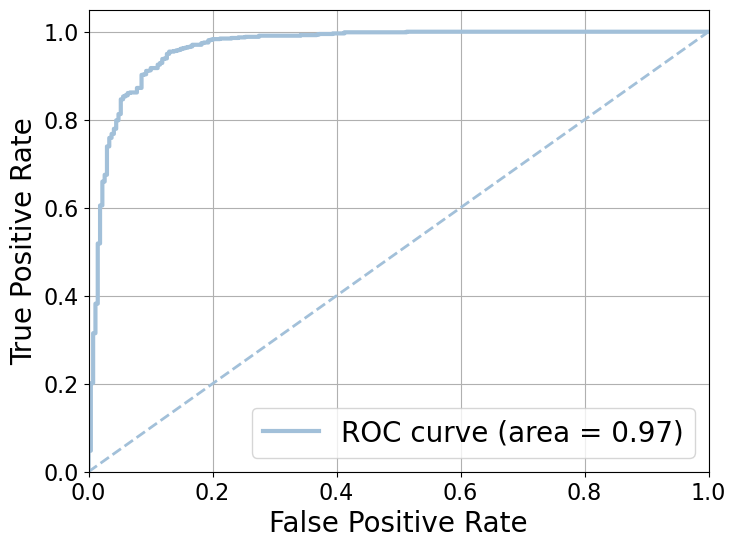

In [8]:
proba_test = final_model.predict_proba(Xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, proba_test)
roc_auc = auc(fpr, tpr)
print(f"test ROC-AUC = {roc_auc:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#A2C0D9', linewidth=3,
         label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='#A2C0D9', linestyle='--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.legend(loc='lower right', fontsize=20)
plt.tick_params(axis='both', labelsize=16)
plt.grid()
plt.savefig('irr_ML.svg', dpi=700, bbox_inches='tight')
plt.show()


## Feature importance

Feature  Importance
 bit145    0.074684
  bit95    0.051349
 bit158    0.046049
 bit111    0.038077
 bit108    0.037822


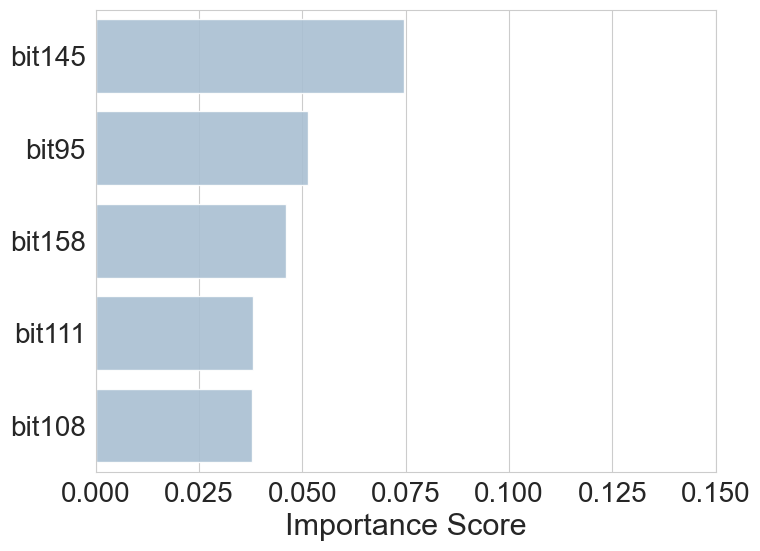

In [9]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_,
}).sort_values(by='Importance', ascending=False)

top5_df = feature_importance_df.head(5)
print(top5_df.to_string(index=False))

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=top5_df,
            color='#A2C0D9', alpha=0.9)
plt.xlabel('Importance Score', fontsize=22)
plt.ylabel('')
plt.xlim(0, 0.15)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.savefig('irr_FI.svg', dpi=700, bbox_inches='tight')
plt.show()


## Save model

Saved with `joblib`, like the other two classifiers, so that
`models/README.md` can document a single loading method.


In [11]:
joblib.dump(final_model, 'irritation.pkl')
print('saved:', type(final_model).__name__, final_params)


saved: GradientBoostingClassifier {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.1}


## Robustness under scaffold splitting

In [12]:
def morgan_fp(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)


def scaffold_of(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    except Exception:
        return None


def scaffold_split(smiles_list, test_size=0.2, seed=RANDOM_STATE):
    """Group compounds by Murcko scaffold and assign whole groups to one
    partition. Groups are filled into the test set largest-first, so the test
    set holds the most populated scaffold families and the training set keeps
    the long tail of singletons."""
    scaffolds = {}
    for idx, smi in enumerate(smiles_list):
        scaffolds.setdefault(scaffold_of(smi), []).append(idx)

    groups = list(scaffolds.values())
    rng = np.random.RandomState(seed)
    groups = [groups[i] for i in rng.permutation(len(groups))]
    groups.sort(key=len, reverse=True)

    n_test_target = int(round(len(smiles_list) * test_size))
    test_idx, train_idx = [], []
    for g in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(g)
        else:
            train_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)


def nn_tanimoto_stats(train_smiles, test_smiles):
    train_fps = [f for f in (morgan_fp(s) for s in train_smiles) if f is not None]
    sims = []
    for s in test_smiles:
        fp = morgan_fp(s)
        if fp is None or not train_fps:
            continue
        sims.append(max(DataStructs.BulkTanimotoSimilarity(fp, train_fps)))
    sims = np.array(sims)
    return {
        'mean_NN_Tanimoto': float(np.mean(sims)) if len(sims) else np.nan,
        'median_NN_Tanimoto': float(np.median(sims)) if len(sims) else np.nan,
        'frac_test_with_NN>0.85': float(np.mean(sims > 0.85)) if len(sims) else np.nan,
        'frac_test_with_NN>0.4': float(np.mean(sims > 0.4)) if len(sims) else np.nan,
    }


In [13]:
smiles_all = df_fp['SMILES'].values
X_all = X.values
y_all = y
idx_all = np.arange(len(y_all))

tr_idx, te_idx = train_test_split(
    idx_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all,
)


In [14]:
def eval_split(train_idx, test_idx, label):
    """Evaluate the final model's configuration on a given partition."""
    m = clone(final_model)
    m.fit(X_all[train_idx], y_all[train_idx])
    proba = m.predict_proba(X_all[test_idx])[:, 1]
    pred = m.predict(X_all[test_idx])
    sims = nn_tanimoto_stats(smiles_all[train_idx], smiles_all[test_idx])

    row = dict(
        label=label,
        n_train=len(train_idx), n_test=len(test_idx),
        train_pos=float(y_all[train_idx].mean()),
        test_pos=float(y_all[test_idx].mean()),
        auc=roc_auc_score(y_all[test_idx], proba),
        f1=f1_score(y_all[test_idx], pred),
        acc=accuracy_score(y_all[test_idx], pred),
        **sims,
    )
    print(f"--- {label} ---")
    print(f"  n_train={row['n_train']} n_test={row['n_test']}  "
          f"train_pos={row['train_pos']:.2f} test_pos={row['test_pos']:.2f}")
    print(f"  ROC-AUC={row['auc']:.3f}  F1={row['f1']:.3f}  Acc={row['acc']:.3f}")
    print(f"  NN-Tanimoto (test->train): mean={row['mean_NN_Tanimoto']:.3f} "
          f"median={row['median_NN_Tanimoto']:.3f}  "
          f"frac>0.85={row['frac_test_with_NN>0.85']:.2f}  "
          f"frac>0.4={row['frac_test_with_NN>0.4']:.2f}")
    return row


results = [eval_split(tr_idx, te_idx, "Random")]

seed_aucs = []
for seed in range(N_SEEDS):
    tr_s, te_s = train_test_split(idx_all, test_size=0.2,
                                  random_state=seed, stratify=y_all)
    m = clone(final_model).fit(X_all[tr_s], y_all[tr_s])
    seed_aucs.append(
        roc_auc_score(y_all[te_s], m.predict_proba(X_all[te_s])[:, 1]))

print(f"\nRandom split ROC-AUC over {N_SEEDS} seeds: "
      f"{np.mean(seed_aucs):.3f} +/- {np.std(seed_aucs):.3f}  "
      f"{[round(a, 3) for a in seed_aucs]}\n")

tr_sc, te_sc = scaffold_split(smiles_all, test_size=0.2, seed=RANDOM_STATE)
results.append(eval_split(tr_sc, te_sc, "Bemis-Murcko scaffold"))

table6 = pd.DataFrame(results)[
    ['label', 'n_train', 'n_test', 'auc',
     'mean_NN_Tanimoto', 'frac_test_with_NN>0.85']
].round(3)

print("\n=== numbers for Table 6 (EI rows) ===")
print(table6.to_string(index=False))
print(f"\n=== hyperparameters for Table 7 ===\n{final_params}")
print(f"\n=== ROC-AUC quoted in the text and in Figure S1 ===\n{roc_auc:.3f}")


--- Random ---
  n_train=4176 n_test=1044  train_pos=0.74 test_pos=0.74
  ROC-AUC=0.965  F1=0.955  Acc=0.933
  NN-Tanimoto (test->train): mean=0.559 median=0.560  frac>0.85=0.05  frac>0.4=0.83

Random split ROC-AUC over 5 seeds: 0.976 +/- 0.002  [0.976, 0.973, 0.978, 0.98, 0.974]

--- Bemis-Murcko scaffold ---
  n_train=3673 n_test=1547  train_pos=0.67 test_pos=0.92
  ROC-AUC=0.956  F1=0.980  Acc=0.963
  NN-Tanimoto (test->train): mean=0.460 median=0.455  frac>0.85=0.00  frac>0.4=0.70

=== numbers for Table 6 (EI rows) ===
                label  n_train  n_test   auc  mean_NN_Tanimoto  frac_test_with_NN>0.85
               Random     4176    1044 0.965             0.559                   0.049
Bemis-Murcko scaffold     3673    1547 0.956             0.460                   0.000

=== hyperparameters for Table 7 ===
{'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.1}

=== ROC-AUC quoted in 